# What do people upload in order to get a map decoded?

The Neurosynth decoder requires you to deposit your map in NeuroVault first.
That flow creates a throwaway collection auto-named
**"\<username\>'s temporary collection"**, which is the only reliable way to
identify it — there is no marker field for it anywhere in the schema.

**The question this answers:** if we redesign the decoder upload flow, what
are people actually giving us, and what is the current form failing to
capture?

Two exclusions apply throughout:

* **Neuroscout** (owner 5761) is dropped — it is a mass upload from a separate
  platform and roughly half of all maps in the database. It never uses the
  temporary-collection flow, so this particular analysis is unaffected, but the
  comparison baselines are.
* The literal string `"None"` is a **real** Cognitive Atlas key meaning
  *"None / Other"*, not a missing value. See `nv_load.py`.

In [1]:
import pandas as pd

from nv_load import (BLANK, answered, blank, barh, cat, is_none_other, load,
                     num, out_dir, save, setup_plots, task_names)

plt = setup_plots()
OUT = out_dir("decoding_uploads")

sm, coll = load()
temp = sm[sm["stratum"] == "temporary"].copy()
temp_coll = coll[coll["is_temporary"]].copy()
rest = sm[sm["stratum"] != "temporary"]
cog = temp["cognitive_paradigm_cogatlas_id"]
rest_cog = rest["cognitive_paradigm_cogatlas_id"]

Loading february_2024  (exclude_neuroscout=True)


  excluded Neuroscout (owner 5761): 3889 collections, 289248 maps (51.7% of all maps)


  analysing 9507 collections / 269934 maps (dump totals: 13396 / 559182)


## 1. How big is the pile, and is anyone still using it?

In [2]:
save(OUT, "01_scale", pd.Series({
    "temporary collections": len(temp_coll),
    "  empty (0 items)": int((temp_coll["n_items"] == 0).sum()),
    "  with more than 1 item": int((temp_coll["n_items"] > 1).sum()),
    "statistic maps within": len(temp),
    "share of all non-Neuroscout maps (%)": round(100 * len(temp) / len(sm), 1),
    "distinct uploading users": temp_coll["owner_id"].nunique(),
}, name="value").to_frame())

,value
temporary collections,3028.0
empty (0 items),1372.0
with more than 1 item,1157.0
statistic maps within,17531.0
share of all non-Neuroscout maps (%),6.5
distinct uploading users,3021.0


A user who decodes repeatedly is a different design target from a one-off
visitor, so it matters whether this is many people once or few people often.

In [3]:
per_user = temp_coll.groupby("owner_id").size()
save(OUT, "02_collections_per_user", pd.Series({
    "users with exactly 1": int((per_user == 1).sum()),
    "users with 2-5": int(per_user.between(2, 5).sum()),
    "users with 6-20": int(per_user.between(6, 20).sum()),
    "users with more than 20": int((per_user > 20).sum()),
    "most by a single user": int(per_user.max()),
}, name="users").to_frame())

,users
users with exactly 1,3014
users with 2-5,7
users with 6-20,0
users with more than 20,0
most by a single user,2


The answer is emphatic: essentially **one collection per user**. This is a
first-visit audience, not a returning power-user base — which argues for
optimising the very first interaction (no login, no bounce to NeuroVault,
minimum fields) over anything that rewards repeat use.

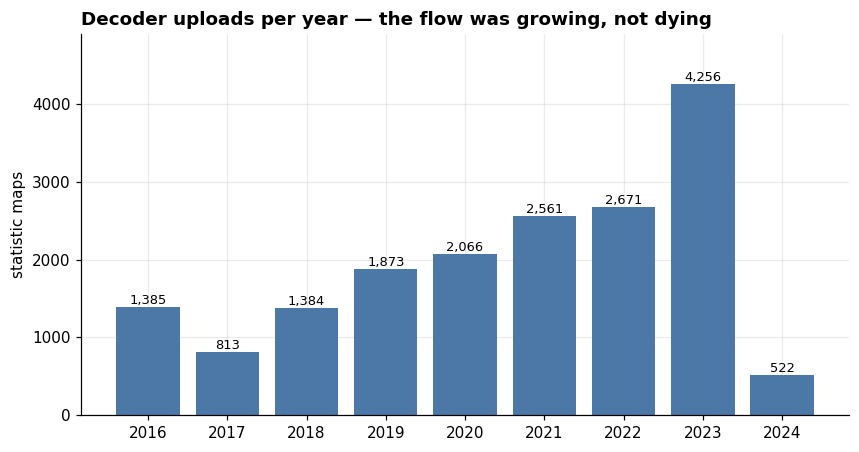

In [4]:
by_year = temp["add_year"].value_counts().sort_index()
save(OUT, "03_maps_by_year", by_year)

fig, ax = plt.subplots()
ax.bar(by_year.index.astype(int).astype(str), by_year.values, color="#4C78A8")
ax.set_title("Decoder uploads per year — the flow was growing, not dying")
ax.set_ylabel("statistic maps")
for x, v in enumerate(by_year.values):
    ax.text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=8.5)
ax.margins(y=0.15)
plt.show()

## 2. What kind of image arrives?

The upload page states an **unthresholded** map is required for decoding to
work properly. Whether users comply is the headline compliance question.

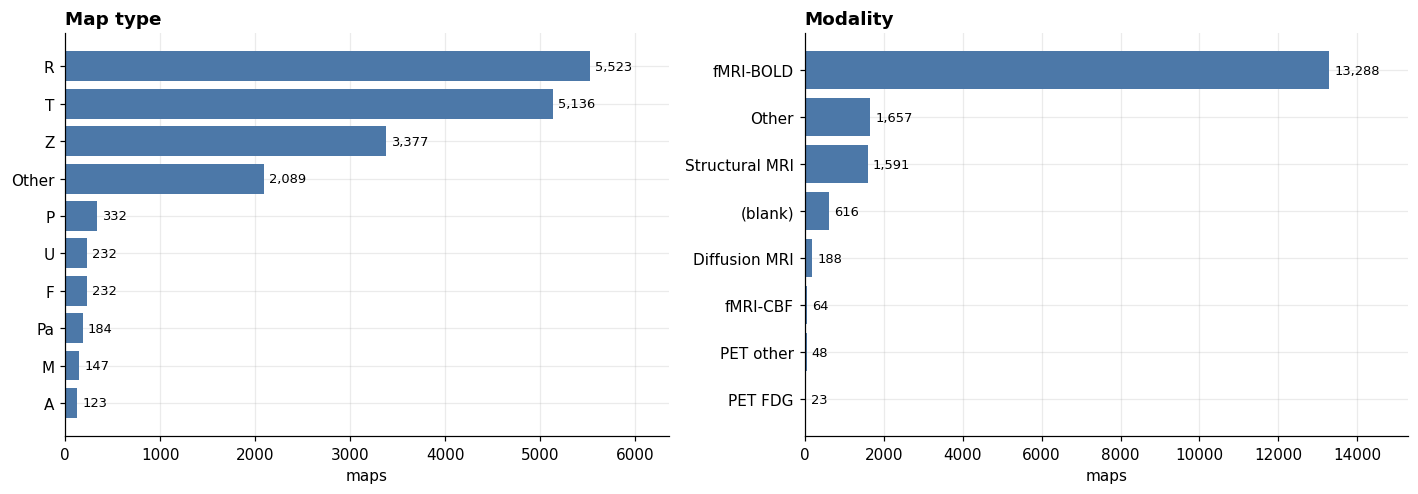

modality
fMRI-BOLD         13288
Other              1657
Structural MRI     1591
(blank)             616
Diffusion MRI       188
fMRI-CBF             64
PET other            48
PET FDG              23
MEG                  22
fMRI-CBV             18
EEG                  16
Name: count, dtype: int64

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
barh(axes[0], temp["map_type"].value_counts().head(10), "Map type")
barh(axes[1], temp["modality"].value_counts().head(8), "Modality")
plt.tight_layout()
plt.show()

save(OUT, "04_map_type", temp["map_type"].value_counts())
save(OUT, "05_modality", temp["modality"].value_counts())

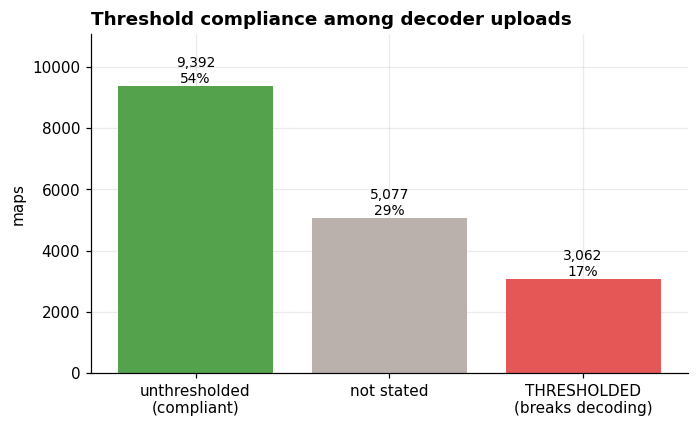

is_thresholded
f          9392
(blank)    5077
t          3062
Name: count, dtype: int64

In [6]:
thr = temp["is_thresholded"].value_counts()
labels = {"f": "unthresholded\n(compliant)", "t": "THRESHOLDED\n(breaks decoding)",
          BLANK: "not stated"}
fig, ax = plt.subplots(figsize=(7, 4))
cols = {"f": "#54A24B", "t": "#E45756", BLANK: "#BAB0AC"}
ax.bar([labels.get(i, i) for i in thr.index], thr.values,
       color=[cols.get(i, "#4C78A8") for i in thr.index])
ax.set_title("Threshold compliance among decoder uploads")
ax.set_ylabel("maps")
for x, v in enumerate(thr.values):
    ax.text(x, v, f"{v:,}\n{100*v/thr.sum():.0f}%", ha="center", va="bottom", fontsize=9)
ax.margins(y=0.18)
plt.show()

save(OUT, "06_thresholded", thr)

An ROI or mask being "thresholded" is expected — a thresholded T or Z map is a
user error that silently degrades their decode.

In [7]:
save(OUT, "07_thresholded_x_maptype",
     pd.crosstab(temp["map_type"], temp["is_thresholded"]))

is_thresholded,(blank),f,t
map_type,,,
(blank),0,1,0
A,0,98,25
F,0,145,87
IP,0,42,48
M,0,96,51
Other,0,1548,541
P,0,275,57
Pa,0,73,111
R,5077,9,437


## 3. What metadata did the flow actually capture?

The form required name, cognitive paradigm, map type, modality and target
template. Everything else was optional — and the gap between those two lists
is the main finding of this notebook.

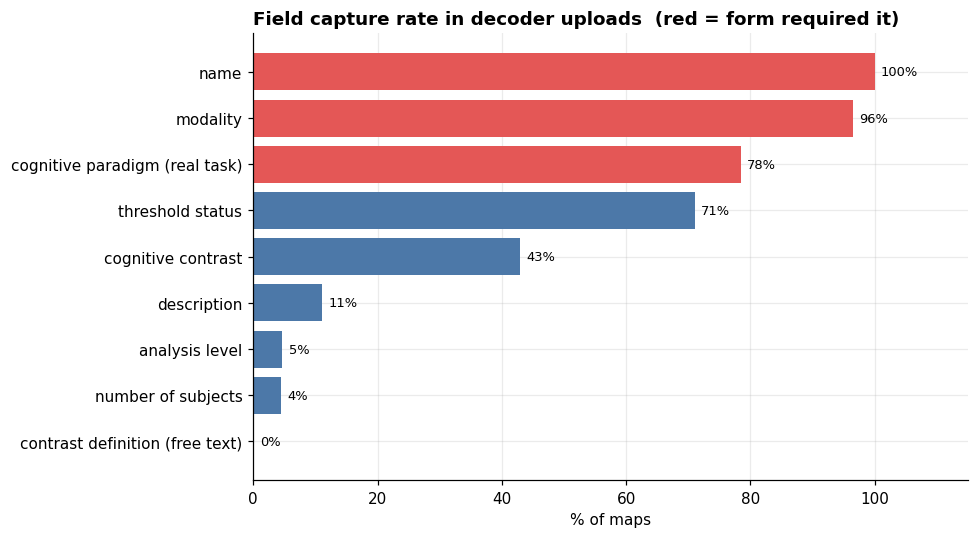

,n,pct
name,17531,100.0
modality,16915,96.5
cognitive paradigm (real task),13769,78.5
threshold status,12454,71.0
cognitive contrast,7523,42.9
description,1951,11.1
analysis level,824,4.7
number of subjects,791,4.5
contrast definition (free text),17,0.1


In [8]:
fields = {
    "name": ~blank(temp["name"]),
    "modality": temp["modality"] != BLANK,
    "threshold status": temp["is_thresholded"] != BLANK,
    "cognitive paradigm (real task)": answered(cog),
    "cognitive contrast": answered(temp["cognitive_contrast_cogatlas_id"]),
    "description": ~blank(temp["description"]),
    "contrast definition (free text)": answered(temp["contrast_definition"]),
    "analysis level": temp["analysis_level"] != BLANK,
    "number of subjects": temp["n_subj"].notna(),
}
capture = pd.Series({k: round(100 * v.mean(), 1) for k, v in fields.items()})
REQUIRED = {"name", "modality", "cognitive paradigm (real task)"}

fig, ax = plt.subplots(figsize=(9, 5))
barh(ax, capture, "Field capture rate in decoder uploads  (red = form required it)",
     xlabel="% of maps", fmt="{:.0f}%", highlight=REQUIRED, highlight_color="#E45756")
plt.tight_layout()
plt.show()

save(OUT, "08_field_capture", pd.DataFrame({
    "n": {k: int(v.sum()) for k, v in fields.items()},
    "pct": capture,
}).sort_values("pct", ascending=False))

Required fields land near the top; optional ones near the bottom. That is the
argument for keeping metadata collection at upload rather than dropping it —
**asking worked**. The flow simply asked for the wrong minimum set.

Compared against the rest of the database (Neuroscout excluded), decoder
uploads are somewhat better on task and dramatically worse on everything that
would make the map reusable afterwards:

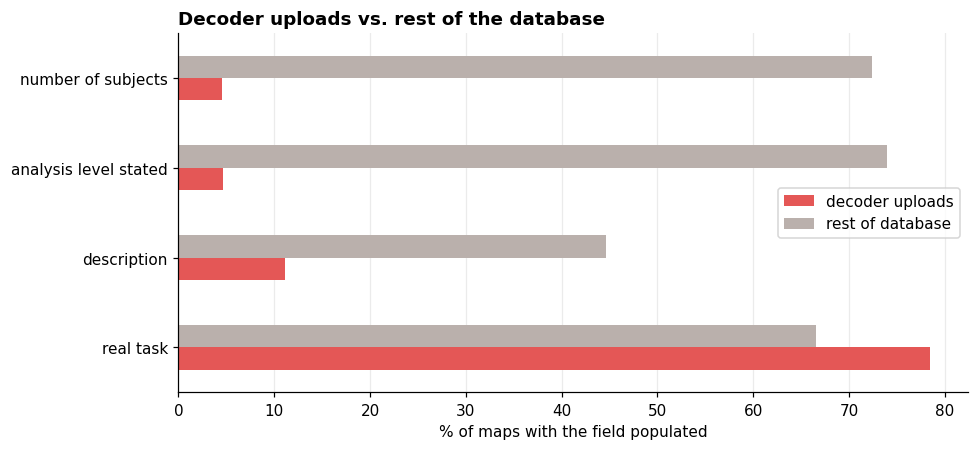

,decoder uploads,rest of database
real task,78.5,66.6
description,11.1,44.6
analysis level stated,4.7,74.0
number of subjects,4.5,72.4


In [9]:
comp = pd.DataFrame({
    "decoder uploads": {
        "real task": 100 * answered(cog).mean(),
        "description": 100 * (~blank(temp["description"])).mean(),
        "analysis level stated": 100 * (temp["analysis_level"] != BLANK).mean(),
        "number of subjects": 100 * temp["n_subj"].notna().mean(),
    },
    "rest of database": {
        "real task": 100 * answered(rest_cog).mean(),
        "description": 100 * (~blank(rest["description"])).mean(),
        "analysis level stated": 100 * (rest["analysis_level"] != BLANK).mean(),
        "number of subjects": 100 * rest["n_subj"].notna().mean(),
    },
}).round(1)

ax = comp.plot(kind="barh", figsize=(9, 4.2), color=["#E45756", "#BAB0AC"])
ax.set_title("Decoder uploads vs. rest of the database")
ax.set_xlabel("% of maps with the field populated")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

save(OUT, "09_capture_vs_rest", comp)

## 4. What are people decoding?

The task distribution among decoder uploads is the closest thing we have to a
demand signal for the Explore and decode vocabulary.

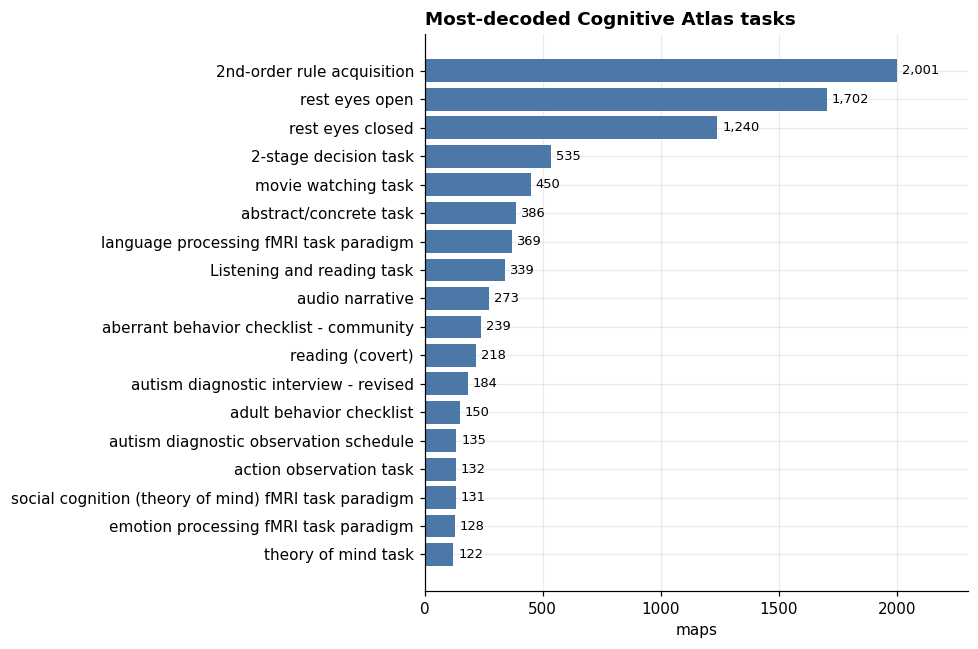

,value
distinct tasks used,417.0
tasks in vocabulary,791.0
vocabulary coverage (%),52.7
top-10 share of selections (%),54.7
explicit 'None / Other',3146.0
left blank,616.0


In [10]:
tasks = task_names()
sel = cog[answered(cog)].value_counts().rename("n")
top = tasks.merge(sel, left_on="cog_atlas_id", right_index=True, how="inner")

fig, ax = plt.subplots(figsize=(9, 6))
s = top.nlargest(18, "n").set_index("name")["n"]
barh(ax, s, "Most-decoded Cognitive Atlas tasks")
plt.tight_layout()
plt.show()

save(OUT, "10_top_tasks_decoded",
     top.sort_values("n", ascending=False)[["name", "cog_atlas_id", "n"]].head(30))
save(OUT, "11_task_coverage", pd.Series({
    "distinct tasks used": int(top.shape[0]),
    "tasks in vocabulary": len(tasks),
    "vocabulary coverage (%)": round(100 * top.shape[0] / len(tasks), 1),
    "top-10 share of selections (%)":
        round(100 * top.nlargest(10, "n")["n"].sum() / max(sel.sum(), 1), 1),
    "explicit 'None / Other'": int(is_none_other(cog).sum()),
    "left blank": int(blank(cog).sum()),
}, name="value").to_frame())

## 5. Quality of what arrives

NeuroVault computes these fields on upload, so they are free to use as a gate
before spending compute on a decode.

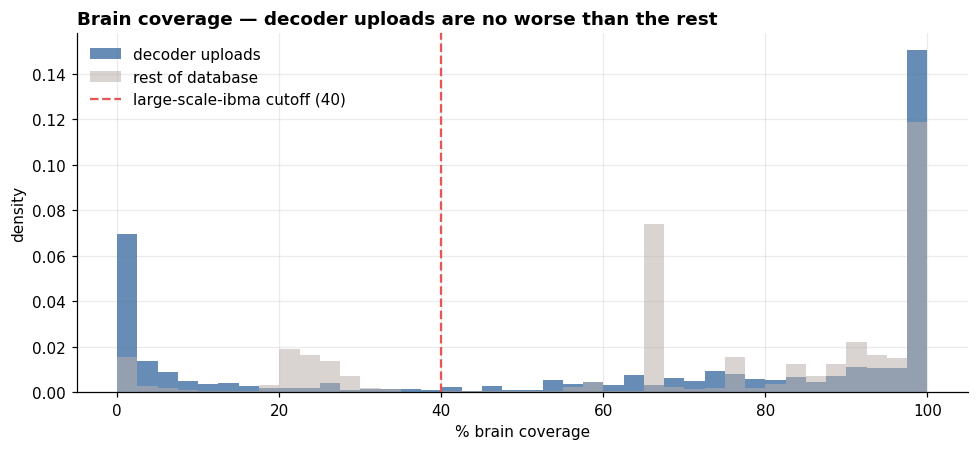

,value
median brain coverage,83.3
"same, rest of database",82.7
brain coverage < 40,5392.0
brain coverage < 50,5689.0
voxels outside template > 25%,5380.0
flagged not_mni,223.0


In [11]:
for c in ["brain_coverage", "perc_voxels_outside"]:
    temp[c] = num(temp[c])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(temp["brain_coverage"].dropna(), bins=40, color="#4C78A8",
        label="decoder uploads", density=True, alpha=0.85)
ax.hist(num(rest["brain_coverage"]).dropna(), bins=40, color="#BAB0AC",
        label="rest of database", density=True, alpha=0.55)
ax.axvline(40, color="#E45756", ls="--", lw=1.5,
           label="large-scale-ibma cutoff (40)")
ax.set_title("Brain coverage — decoder uploads are no worse than the rest")
ax.set_xlabel("% brain coverage")
ax.set_ylabel("density")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

save(OUT, "12_quality_flags", pd.Series({
    "median brain coverage": round(temp["brain_coverage"].median(), 1),
    "  same, rest of database": round(num(rest["brain_coverage"]).median(), 1),
    "brain coverage < 40": int((temp["brain_coverage"] < 40).sum()),
    "brain coverage < 50": int((temp["brain_coverage"] < 50).sum()),
    "voxels outside template > 25%": int((temp["perc_voxels_outside"] > 25).sum()),
    "flagged not_mni": int((cat(temp["not_mni"]) == "t").sum()),
}, name="value").to_frame())

## Takeaways for the upload redesign

1. **Asking works.** Every field the form required is populated at a high rate;
   every optional field is not. Keep collecting metadata at upload.
2. **It asked for the wrong minimum set.** `analysis_level` and sample size are
   both near-empty, and those are exactly the two fields that decide whether a
   map is reusable for meta-analysis afterwards.
3. **Two silent failures to fix:** maps arriving thresholded despite the
   instruction, and collections abandoned empty.
4. **There is real demand.** Usage grew through 2023, and the task mix is a
   ready-made popularity signal for what the decode vocabulary should cover.

In [12]:
print(f"Wrote {len(list(OUT.glob('*.csv')))} tables to {OUT}/")

Wrote 12 tables to audit_output/february_2024/decoding_uploads/
